# **<span style="font-family: Arial">Financial Fraud Detection - Initial EDA </span>**

**Author:** Ozor Moya

**Date:** 04/19/2026

## Project Objective

- This project involves analyzing a synthetic bank transaction dataset using Python (Pandas, Numpy, Seaborn, Matplotlib) to perform exploratory data analysis and uncover fraud patterns. Machine learning algorithms are implemented and evaluated to build predictive models that maximize fraud detection accuracy while minimizing false positives.

### Exploratory Data Analysis

**Goal:** To explore the underlying structure, patterns, relationships, and anomalies within the data.

---
### 1. Import necessary libraries 

In [13]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

---
### 2. Data loading

In [ ]:
# Load the data
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/P2PortfolioProject/Data/PS_20174392719_1491204439457_log.csv')

---

### 3. First look at the data

In [7]:
# Check how many rows and columns of the data
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

# Check how the dataset looks like
df.head()

Rows: 6362620
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


---
### 4. Check elements of the data

In [8]:
# Check column names, null values and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Column descriptions as stated on the Financial Fraud Dataset lab:

- 1. `step`: Unit of time (1 step = 1 hour, max 744 = 30 days)
- 2. `type`: Transaction type: CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER
- 3. `amount`: The amount of money transferred 
- 4. `nameOrig`: The origin account name
- 5. `oldbalanceOrg`: The origin accounts balance before the transaction 
- 6. `newbalanceOrig`: The origin accounts balance after the transaction
- 7. `nameDest`: The destination account name
- 8. `oldbalanceDest`: The destination accounts balance before the transaction 
- 9. `newbalanceDest`: The destination accounts balance after the transaction
- 10. `isFraud`: Target variable (1 = fraudulent, 0 = not fraudulent)
- 11. `isFlaggedFraud`: System flag for transactions over 200k (mostly useless, very few flagged)

In [ ]:
# Getting insight for numerical dataset
df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


- Here I rounded the dataset into two decimal places by using round method for easy readability.

---
### 6. Checking columns with missing values and duplicates

In [11]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


- This dataset does not contain any missing or null values despite having 6 millions rows which is good, since there is no need to handle or drop missing or null values.

In [12]:
# Check for duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


- No duplicate rows, good to proceed.

---
### 7. Univariate Analysis

#### 7.1 Univariate analysis for `balance columns` (Raw)

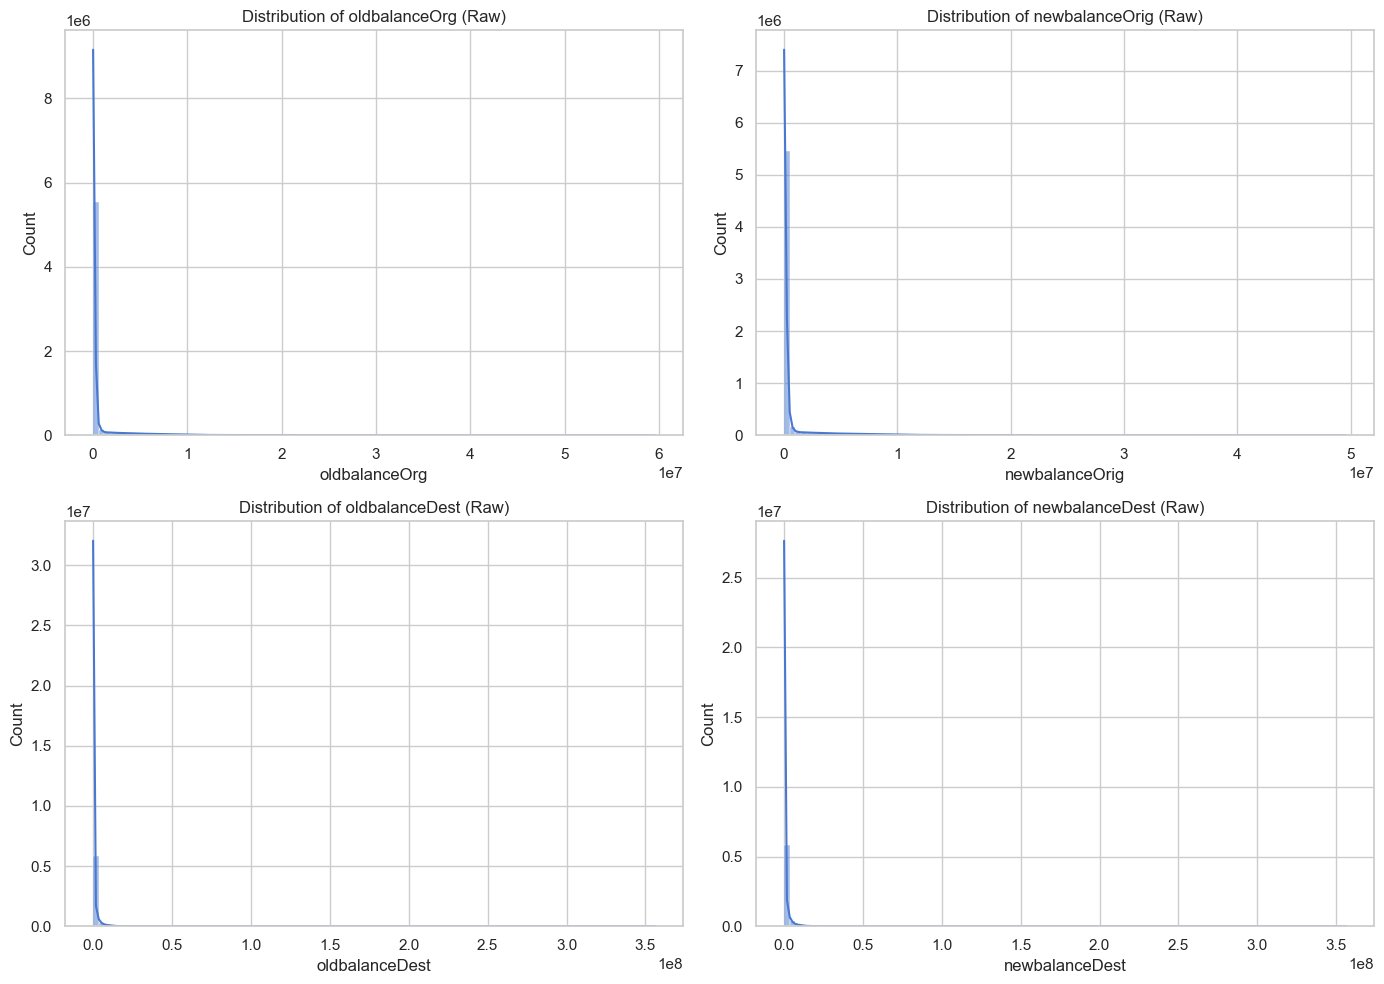

In [85]:
bal_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(bal_cols):
    sns.histplot(df[col], bins=100, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (Raw)')
    axes[i].set_xlabel(col)

plt.tight_layout()

All four columns have a massive spike at zero — but the reason differs:

- `oldbalanceOrg` & `newbalanceOrig` — many sender accounts start with zero or end with zero after a transaction. Accounts being completely drained is worth noting as a potential fraud signal
- `oldbalanceDest` & `newbalanceDest` — many destination accounts show zero balance, which in this dataset is linked to merchant accounts that don't record balances

- All balance columns are heavily right-skewed with significant zero inflation. Sender balance columns suggest many accounts are completely drained after transactions, while destination balance zeros are attributed to merchant accounts that do not track balances. A log transformation will be applied to reveal the underlying distributions more clearly.

---
#### 7.2 Univariate analysis for `balance columns` (Log Transform)

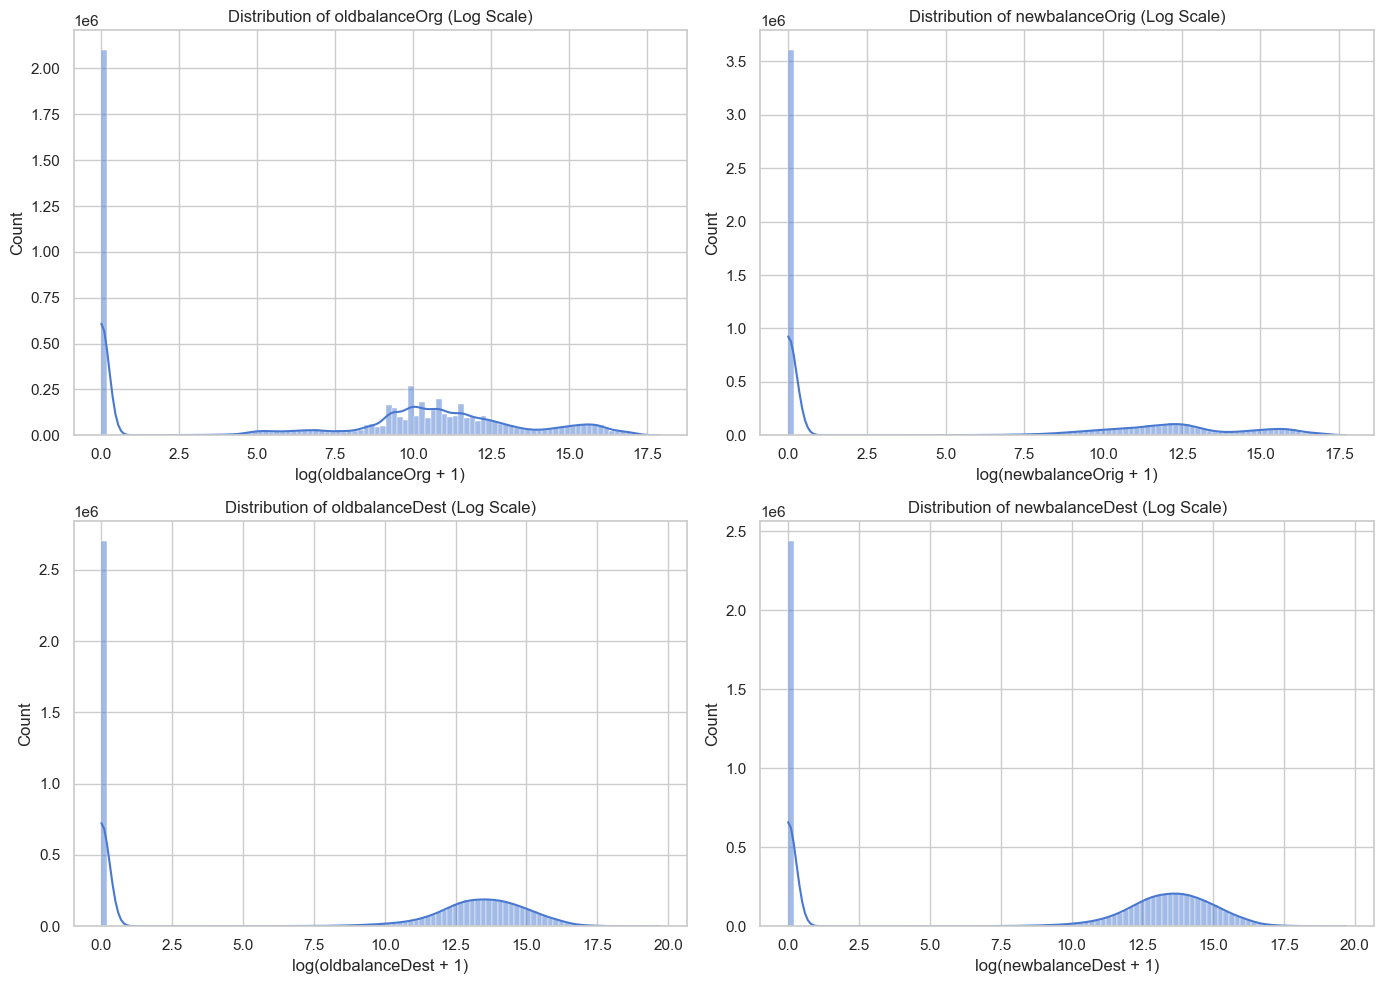

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(bal_cols):
    sns.histplot(np.log1p(df[col]), bins=100, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (Log Scale)')
    axes[i].set_xlabel(f'log({col} + 1)')

plt.tight_layout()

`oldbalanceOrg`

Zero spike = senders with no balance before transacting
Hump around log(9–12) = senders with a moderate to high balance before transacting
Two very different types of account holders

`newbalanceOrig`

Zero spike is much taller than oldbalanceOrg — meaning after transactions, far more accounts end up at zero
The hump is much smaller and flatter — fewer accounts retain a significant balance after transacting
This gap between old and new balance is a strong fraud signal worth revisiting in bivariate analysis

`oldbalanceDest` & `newbalanceDest`

Zero spike = destination accounts with no recorded balance (merchant accounts)
Hump around log(13–15) = destination accounts with large balances
The two groups are very clearly separated with almost nothing in between

- After log transformation, all balance columns reveal a bimodal structure — a large zero cluster and a secondary hump representing accounts with substantial balances. Notably, newbalanceOrig has a significantly larger zero spike compared to oldbalanceOrg, suggesting many accounts are completely drained after transactions. This pattern may serve as an important fraud indicator and will be explored further in bivariate analysis.

---
#### 7.3 Univariate Analysis for `amount` column (Raw)

Text(0.5, 0, 'Amount')

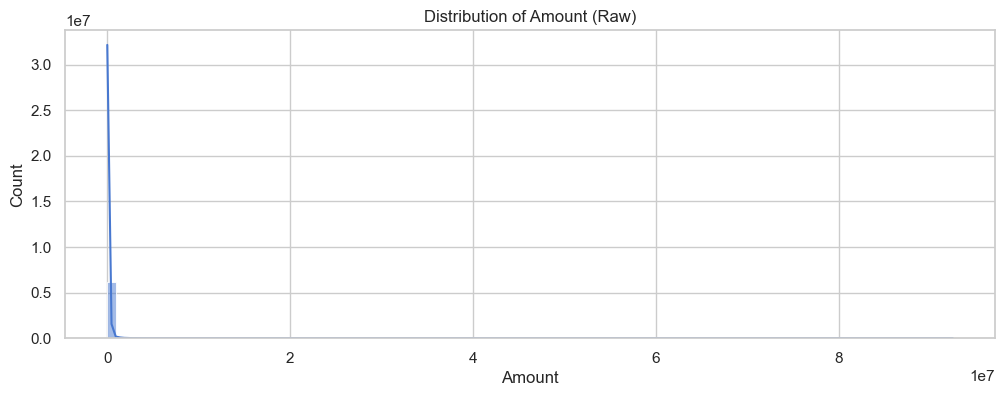

In [46]:
plt.figure(figsize=(12, 4))
sns.histplot(df['amount'], bins=100, kde=True)
plt.title('Distribution of Amount (Raw)')
plt.xlabel('Amount')

- The amount column shows a strong right skew — the majority of transactions are small in value while a small number of extremely large transactions stretch the distribution to the right. Unlike the balance columns, there is no zero spike since every transaction must have a positive amount. The mean is significantly higher than the median, confirming the influence of large outlier transactions. A log transformation will be applied to better visualize the underlying distribution.

---
#### 7.4 Univariate Analysis for `amount` column (Log Transform)

Text(0.5, 0, 'log(Amount + 1)')

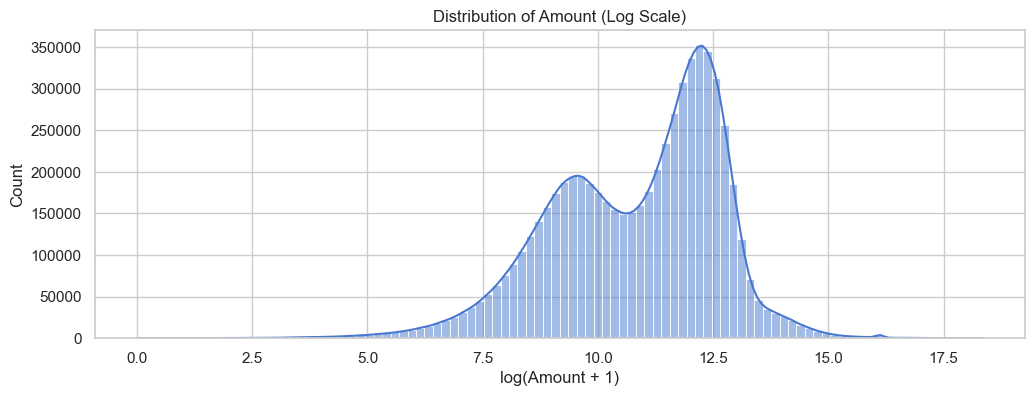

In [53]:
plt.figure(figsize=(12, 4))
sns.histplot(np.log1p(df['amount']), bins=100, kde=True)
plt.title('Distribution of Amount (Log Scale)')
plt.xlabel('log(Amount + 1)')

The two peaks suggest there are two distinct groups of transactions in the dataset:

First peak (smaller amounts) — likely everyday retail transactions such as payments, small cash outs, debits. These are high frequency and low value

Second peak (larger amounts) — likely larger financial movements such as transfers and bigger cash outs. These are less frequent but higher value

- After log transformation, the amount column reveals a bimodal distribution with two distinct peaks — one around log(9–10) representing smaller everyday transactions, and a larger peak around log(12–12.5) representing higher value financial movements. This suggests two fundamentally different transaction behaviors coexist in the dataset. The relationship between these clusters and fraud will be explored in the bivariate analysis.

---
#### 7.5 Univariate Analysis for `step` column

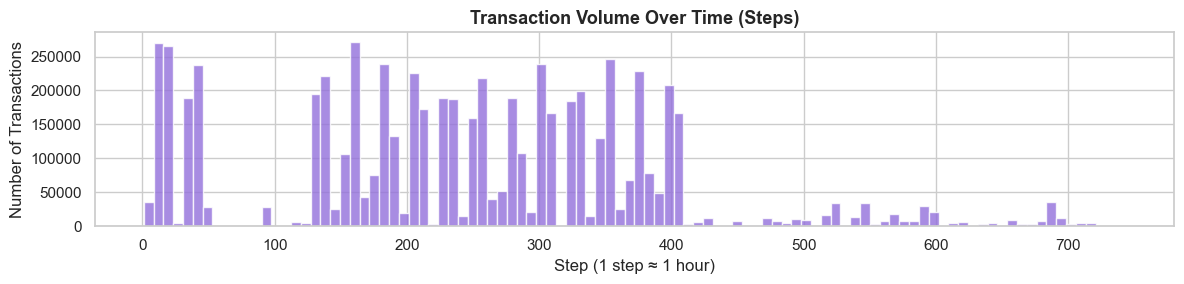

In [56]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.hist(df['step'], bins=100, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.set_title('Transaction Volume Over Time (Steps)', fontsize=13, fontweight='bold')
ax.set_xlabel('Step (1 step ≈ 1 hour)')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

- Transaction volume is heavily concentrated within the first 400 hours (~17 days) of the simulation, with an irregular spiking pattern suggesting daily cycles of activity. After step 400, activity drops sharply to near zero. This temporal pattern may have implications for fraud detection as fraudulent behavior could cluster around specific time windows, which will be explored in bivariate analysis.

---
#### 7.6 Univariate Analysis for Transaction Types (categorical values)

- The `type` column tells what kind of transaction occurred. I will analyze each type to understand what's most common in this dataset.

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


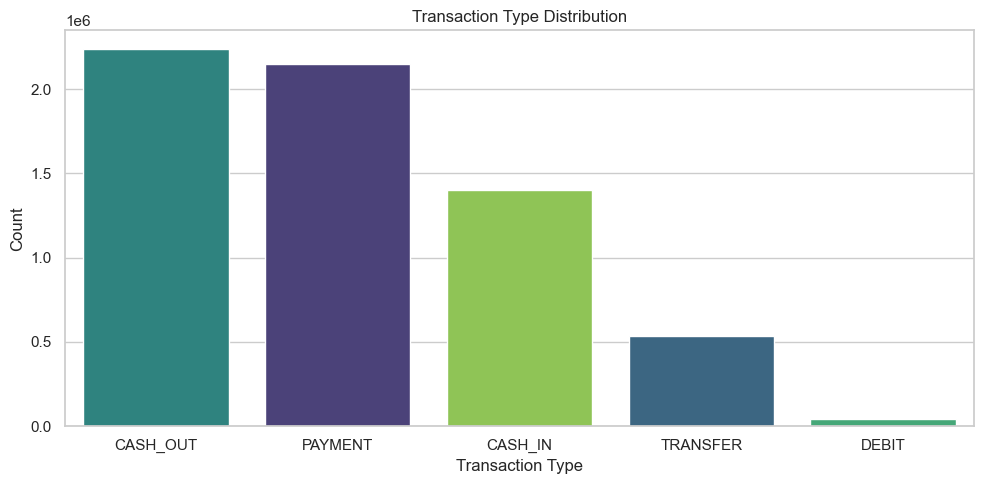

In [35]:
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure(figsize=(10, 5))
sns.countplot(x='type', data=df, order=type_counts.index, hue='type', palette='viridis')
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()

- CASH_OUT and PAYMENT dominate transaction volume, together accounting for nearly 70% of all transactions. CASH_IN follows at 22%, while TRANSFER and DEBIT are relatively rare. The relationship between transaction type and fraud will be explored in the bivariate analysis.

---
#### 7.7 Univariate Analysis for Class Distribution

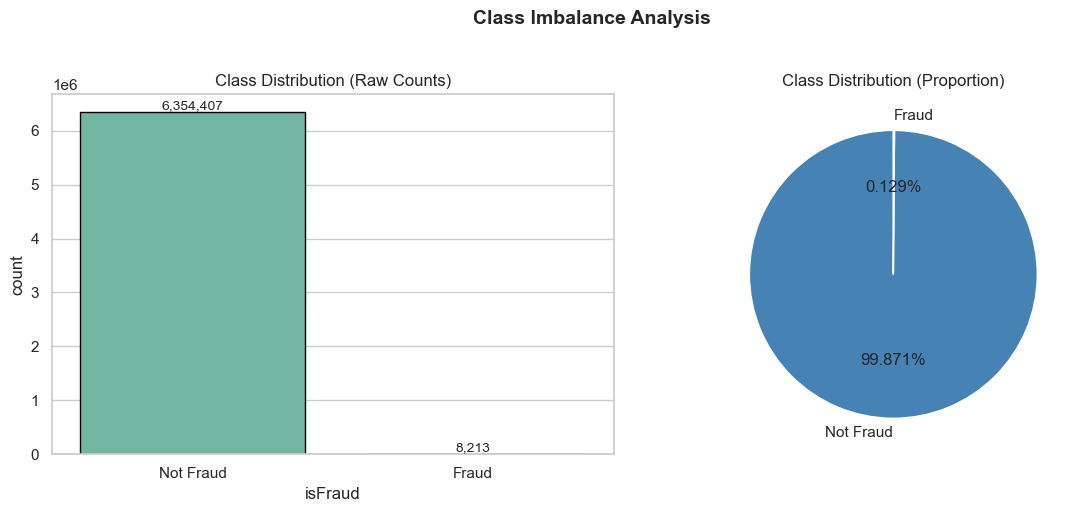

In [57]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='isFraud', data=df, ax=axes[0], hue='isFraud', 
              palette='Set2', edgecolor='black')
axes[0].legend_.remove()
axes[0].set_title('Class Distribution (Raw Counts)')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 50000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts, labels=['Not Fraud', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue','coral'], startangle=90)
axes[1].set_title('Class Distribution (Proportion)')

plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

- The target variable is severely imbalanced — only 0.129% of transactions are fraudulent. This means a naive model predicting "Not Fraud" for all cases would achieve 99.871% accuracy while catching zero fraud. Accuracy is therefore a misleading metric for this problem. Model performance will instead be evaluated using Precision, Recall, F1-Score and AUC-ROC. Class imbalance will be addressed during modeling using techniques such as class weighting or SMOTE.

---
### 8. Bivariate Analysis

- Bivariate analysis explores the relationship between each feature and the target variable isFraud. The goal is to identify which features show meaningful differences between fraudulent and legitimate transactions, which will inform feature selection and engineering during modeling.

#### 8.1 Fraud vs Transaction Type

       type  fraud_count  fraud_rate
4  TRANSFER         4097        0.77
1  CASH_OUT         4116        0.18
0   CASH_IN            0        0.00
2     DEBIT            0        0.00
3   PAYMENT            0        0.00


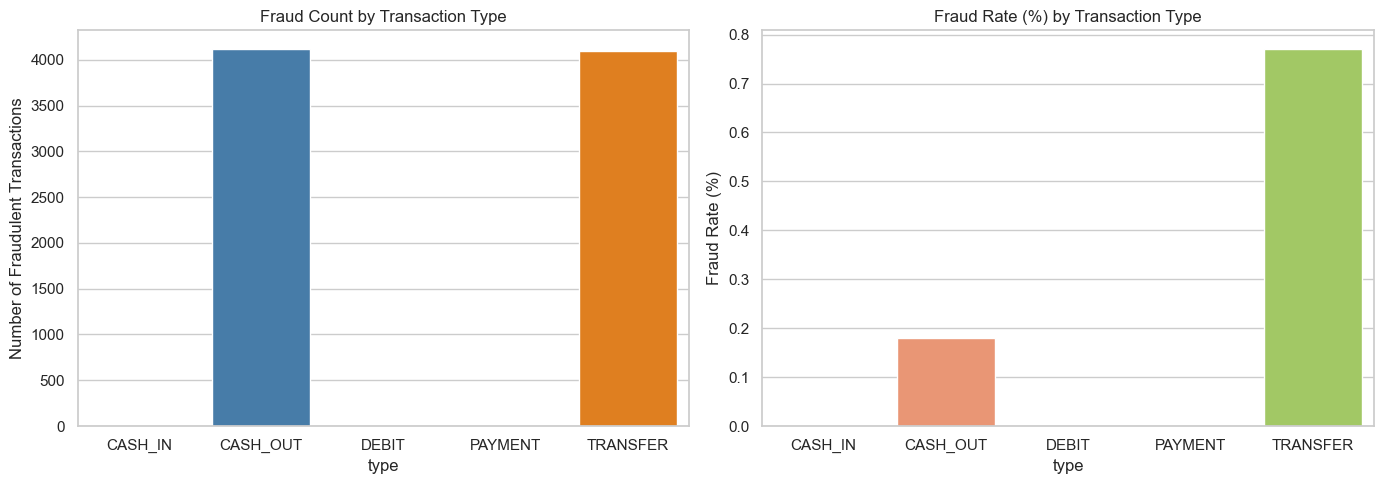

In [60]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_by_type.columns = ['type', 'fraud_count', 'fraud_rate']
fraud_by_type['fraud_rate'] = (fraud_by_type['fraud_rate'] * 100).round(2)
print(fraud_by_type.sort_values('fraud_rate', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='type', y='fraud_count', data=fraud_by_type, ax=axes[0], hue='type', palette='Set1')
axes[0].set_title('Fraud Count by Transaction Type')
axes[0].set_ylabel('Number of Fraudulent Transactions')

sns.barplot(x='type', y='fraud_rate', data=fraud_by_type, ax=axes[1], hue='type', palette='Set2')
axes[1].set_title('Fraud Rate (%) by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()

`Left chart — Fraud Count`

- CASH_OUT and TRANSFER have almost equal numbers of fraud cases (~4,100 each), splitting the total 8,213 fraud cases roughly 50/50. At first glance they look equally risky.

`Right chart — Fraud Rate`

- CASH_OUT fraud rate: ~0.18% — only 1 in every 556 CASH_OUT transactions is fraudulent

- TRANSFER fraud rate: ~0.77% — 1 in every 130 TRANSFER transactions is fraudulent

- Fraud is exclusively concentrated in TRANSFER and CASH_OUT transactions. While both types have similar raw fraud counts (~4,100 each), TRANSFER has a significantly higher fraud rate at 0.77% compared to CASH_OUT at 0.18% — meaning a TRANSFER transaction is approximately 4 times more likely to be fraudulent. This reflects a common real world fraud pattern where money is first transferred to a mule account and then cashed out. Transaction type is therefore a strong predictive feature and will be retained in the model.

---
#### 8.2 Fraud vs Amount

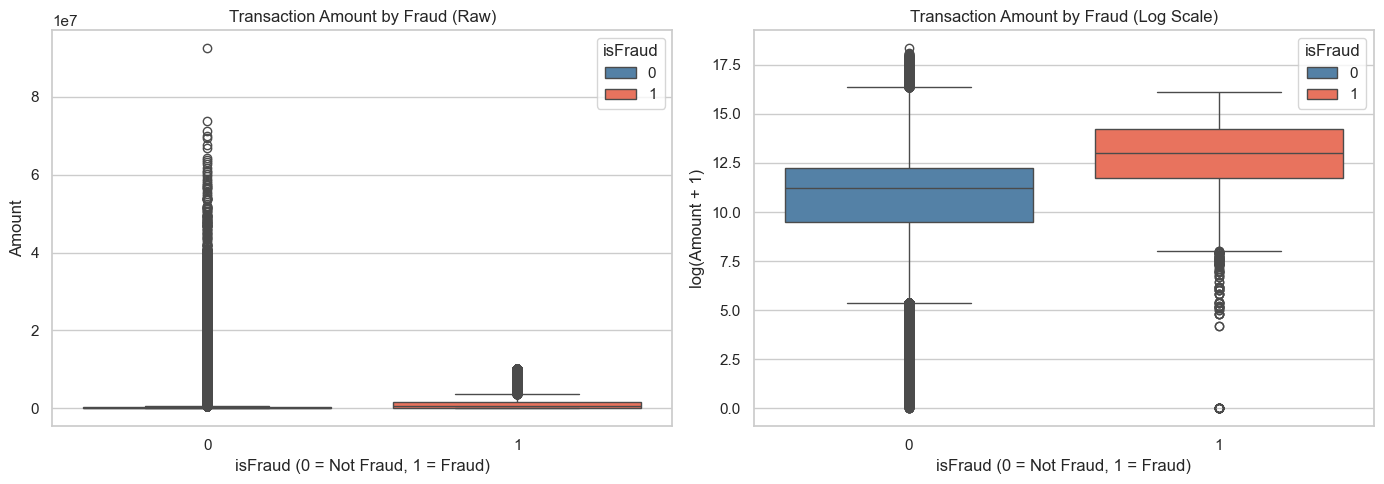

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw boxplot
sns.boxplot(data=df, x='isFraud', y='amount', ax=axes[0], hue='isFraud', palette=['steelblue', 'tomato'])
axes[0].set_title('Transaction Amount by Fraud (Raw)')
axes[0].set_xlabel('isFraud (0 = Not Fraud, 1 = Fraud)')
axes[0].set_ylabel('Amount')

# Log transformed boxplot
sns.boxplot(data=df, x='isFraud', y=np.log1p(df['amount']), ax=axes[1], hue='isFraud', palette=['steelblue', 'tomato'])
axes[1].set_title('Transaction Amount by Fraud (Log Scale)')
axes[1].set_xlabel('isFraud (0 = Not Fraud, 1 = Fraud)')
axes[1].set_ylabel('log(Amount + 1)')

plt.tight_layout()

`Left chart — Raw Boxplot`

- The Not Fraud (0) box is completely flat near zero with tons of outlier dots stretching up to 90M — the extreme values make the box itself invisible

- The Fraud (1) box is slightly more visible but still heavily compressed

`Right chart — Log Scale Boxplot`

Not Fraud (0):

- Box spans roughly log(9.5) to log(12) — moderate transaction amounts

- Very long whisker downward — many small legitimate transactions

- Outliers scattered across the full range


Fraud (1):

- Box spans roughly log(12) to log(14) — noticeably higher than non-fraud

- The entire box is shifted to the right compared to non-fraud

- Median is higher — meaning the typical fraud transaction is larger than the typical legitimate transaction

- Tighter box — fraud transactions are more concentrated in a specific amount range

- Fraudulent transactions tend to involve significantly higher amounts than legitimate ones. The log-scaled boxplot clearly shows the fraud distribution shifted to the right, with a higher median and tighter interquartile range. This suggests fraudsters tend to target mid-to-high value transactions rather than very small ones, making transaction amount a potentially useful predictive feature.

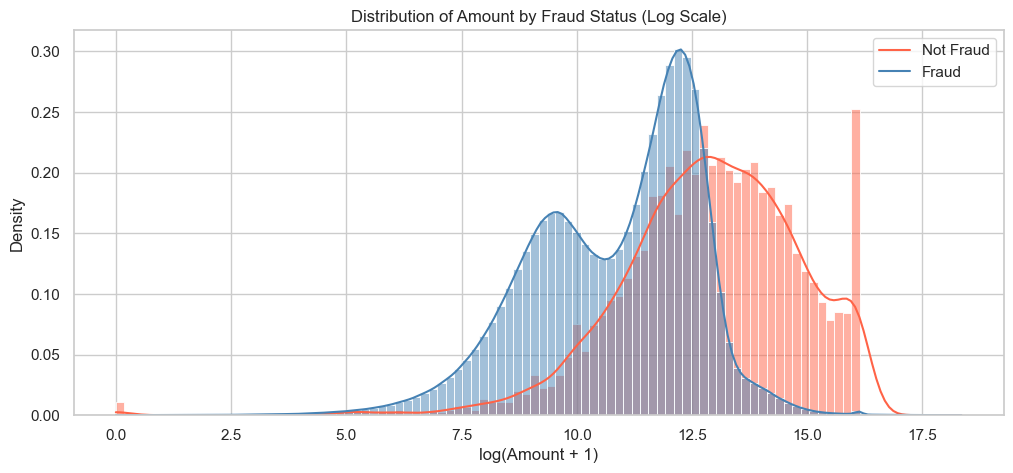

In [66]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x=np.log1p(df['amount']), hue='isFraud',
             bins=100, kde=True, palette=['steelblue', 'tomato'],
             alpha=0.5, stat='density', common_norm=False)
plt.title('Distribution of Amount by Fraud Status (Log Scale)')
plt.xlabel('log(Amount + 1)')
plt.legend(labels=['Not Fraud', 'Fraud'])
plt.show()

- When normalized for class imbalance, the amount distributions for fraud and non-fraud show significant overlap, suggesting amount alone is not sufficient to classify fraud. However fraud transactions are notably concentrated in the mid-to-high range (log 10–13) while legitimate transactions have a wider spread including very small and very large amounts. Fraudsters appear to target a specific amount range — large enough to be profitable but not so extreme as to trigger immediate detection. Amount will be retained as a feature but will need to be combined with other variables for effective fraud detection.

---
#### 8.3 Fraud vs Balance Variance

In [67]:
# Using median instead of mean because of the skewed distributions and outliers.
print(df.groupby('isFraud')[bal_cols].median())

         oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
isFraud                                                               
0             14069.00             0.0        133311.8       214881.70
1            438983.45             0.0             0.0         4676.42


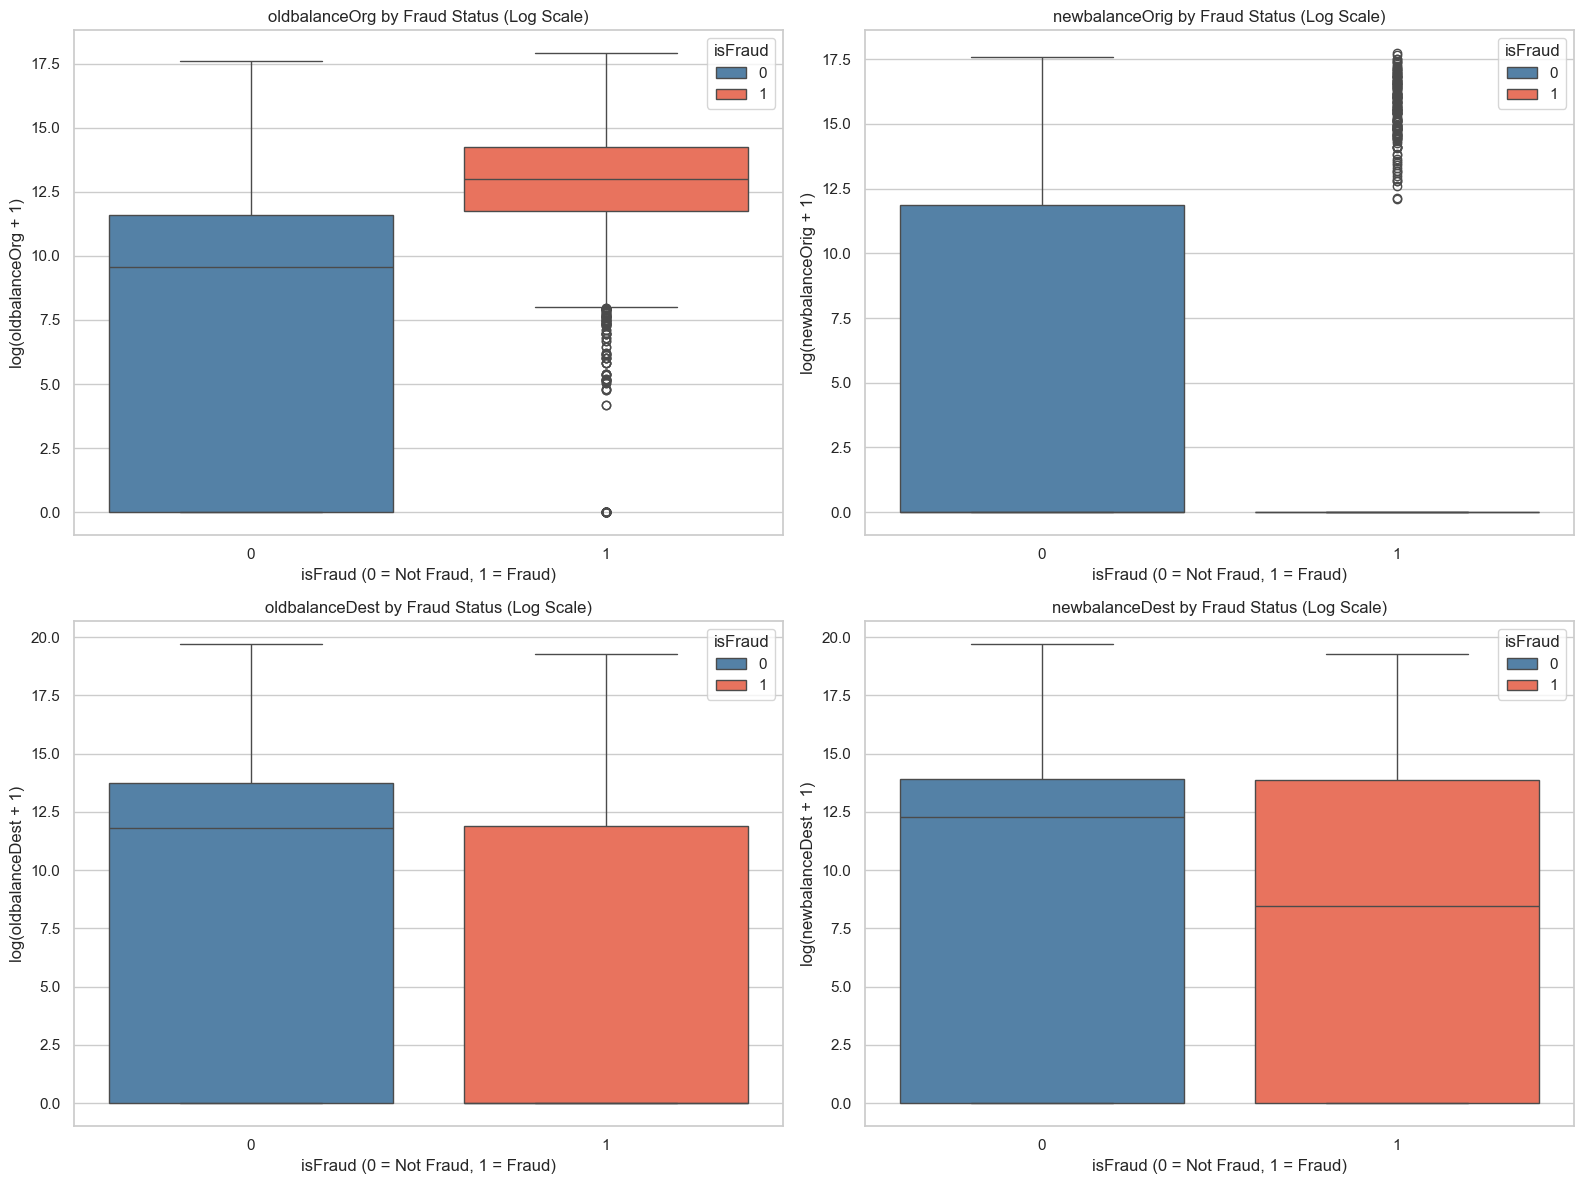

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(bal_cols):
    sns.boxplot(data=df, x='isFraud', y=np.log1p(df[col]), 
                ax=axes[i], hue='isFraud', palette=['steelblue', 'tomato'])
    axes[i].set_title(f'{col} by Fraud Status (Log Scale)')
    axes[i].set_xlabel('isFraud (0 = Not Fraud, 1 = Fraud)')
    axes[i].set_ylabel(f'log({col} + 1)')

plt.tight_layout()

- The balance columns reveal strong fraud signals particularly on the sender side. Fraudulent transactions originate from accounts with significantly higher pre-transaction balances, and almost universally result in the sender's account being completely drained to zero. This pattern strongly suggests fraud involves deliberate and complete emptying of victim accounts. Destination balance columns show weaker but still notable differences, with fraud destinations tending to have lower pre-transaction balances consistent with newly created mule accounts. oldbalanceOrg and newbalanceOrig are expected to be among the most predictive features in the model.

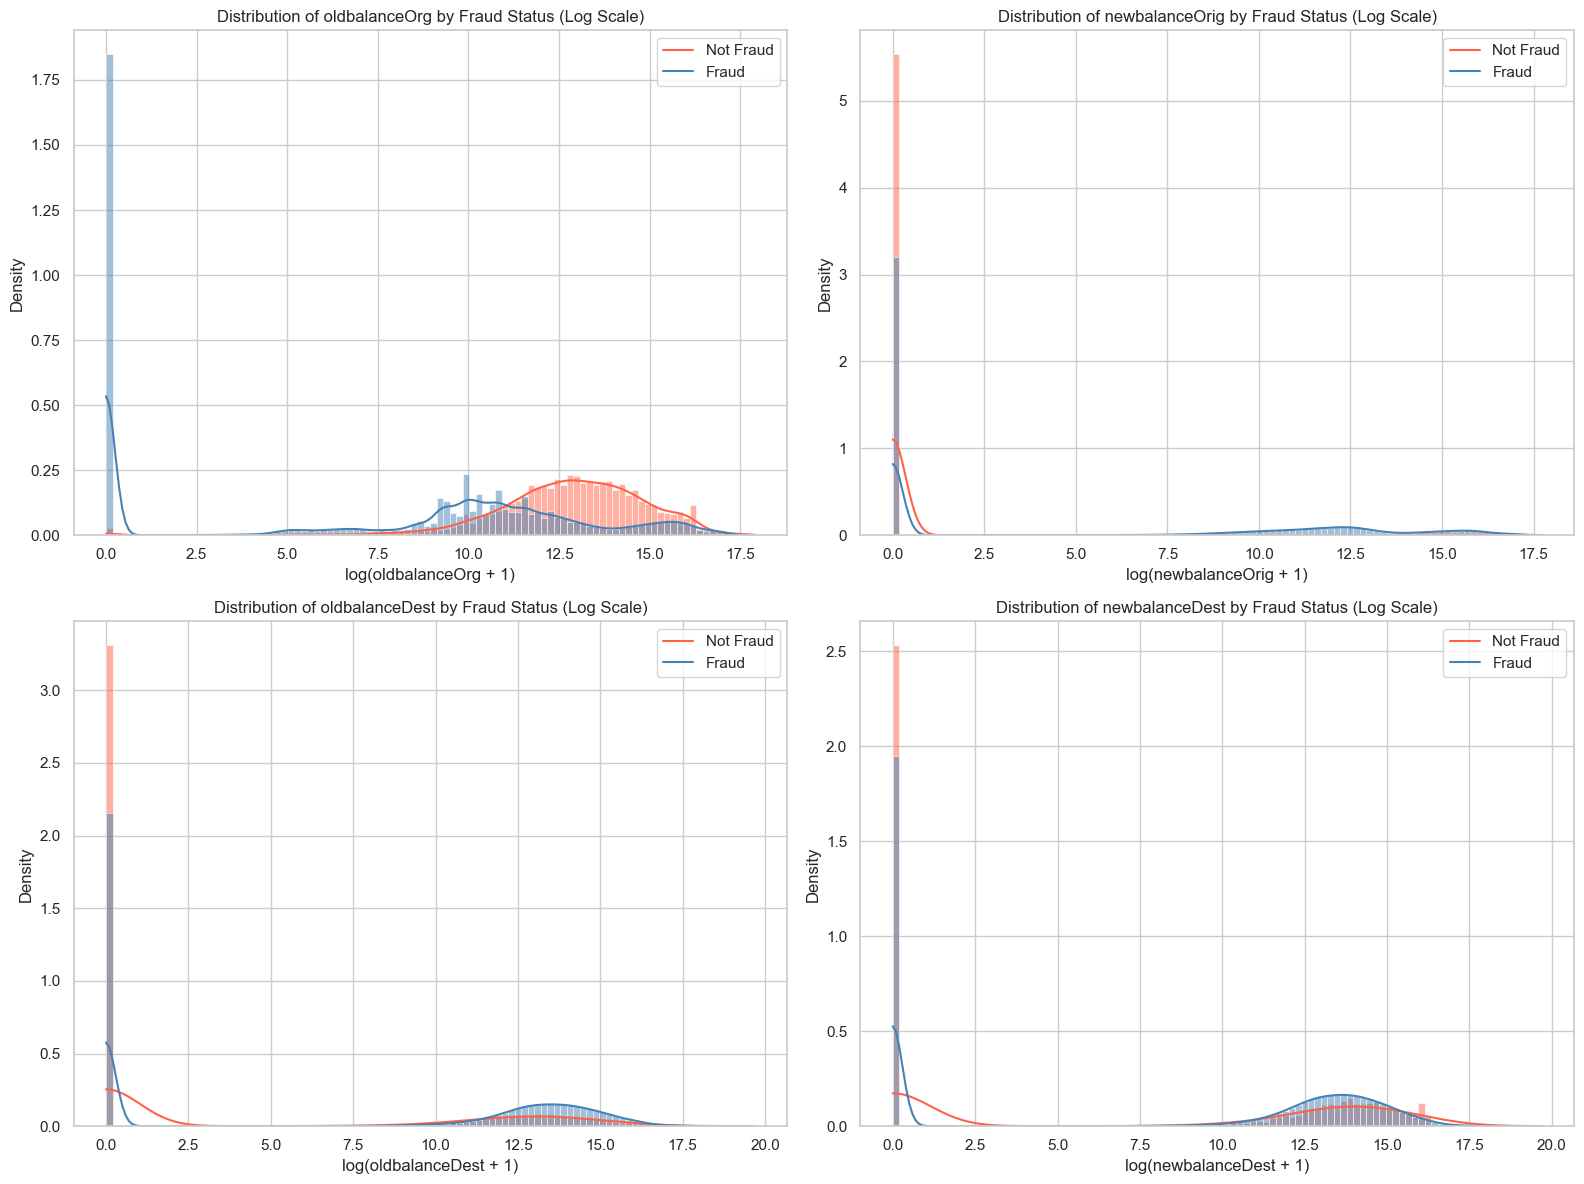

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(bal_cols):
    sns.histplot(data=df, x=np.log1p(df[col]), hue='isFraud',
                bins=100, kde=True, palette=['steelblue', 'tomato'],
                alpha=0.5, stat='density', common_norm=False, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Fraud Status (Log Scale)')
    axes[i].set_xlabel(f'log({col} + 1)')
    axes[i].legend(labels=['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

- While the boxplots provide a clear summary comparison of central tendencies, the density plots reveal additional structure — particularly the zero concentration in newbalanceOrig for fraud cases, confirming that fraudulent transactions almost universally drain the sender account to zero. The destination balance columns show minimal separation between fraud and non-fraud, suggesting they are weaker predictive features compared to the sender balance columns.

---
#### 8.4 Fraud vs Time(step)

In [72]:
fraud_over_time = df.groupby('step')['isFraud'].agg(['sum', 'count'])
fraud_over_time.columns = ['fraud_count', 'total_count']
fraud_over_time['fraud_rate'] = fraud_over_time['fraud_count'] / fraud_over_time['total_count'] * 100
print(fraud_over_time.head(10))

      fraud_count  total_count  fraud_rate
step                                      
1              16         2708    0.590842
2               8         1014    0.788955
3               4          552    0.724638
4              10          565    1.769912
5               6          665    0.902256
6              22         1660    1.325301
7              12         6837    0.175516
8              12        21097    0.056880
9              19        37628    0.050494
10             11        35991    0.030563


- Here I observed that even in the first hour of transaction, there is already a fraudulent activity happening. Actually, the fraudulent activities happens all the time with this dataset.

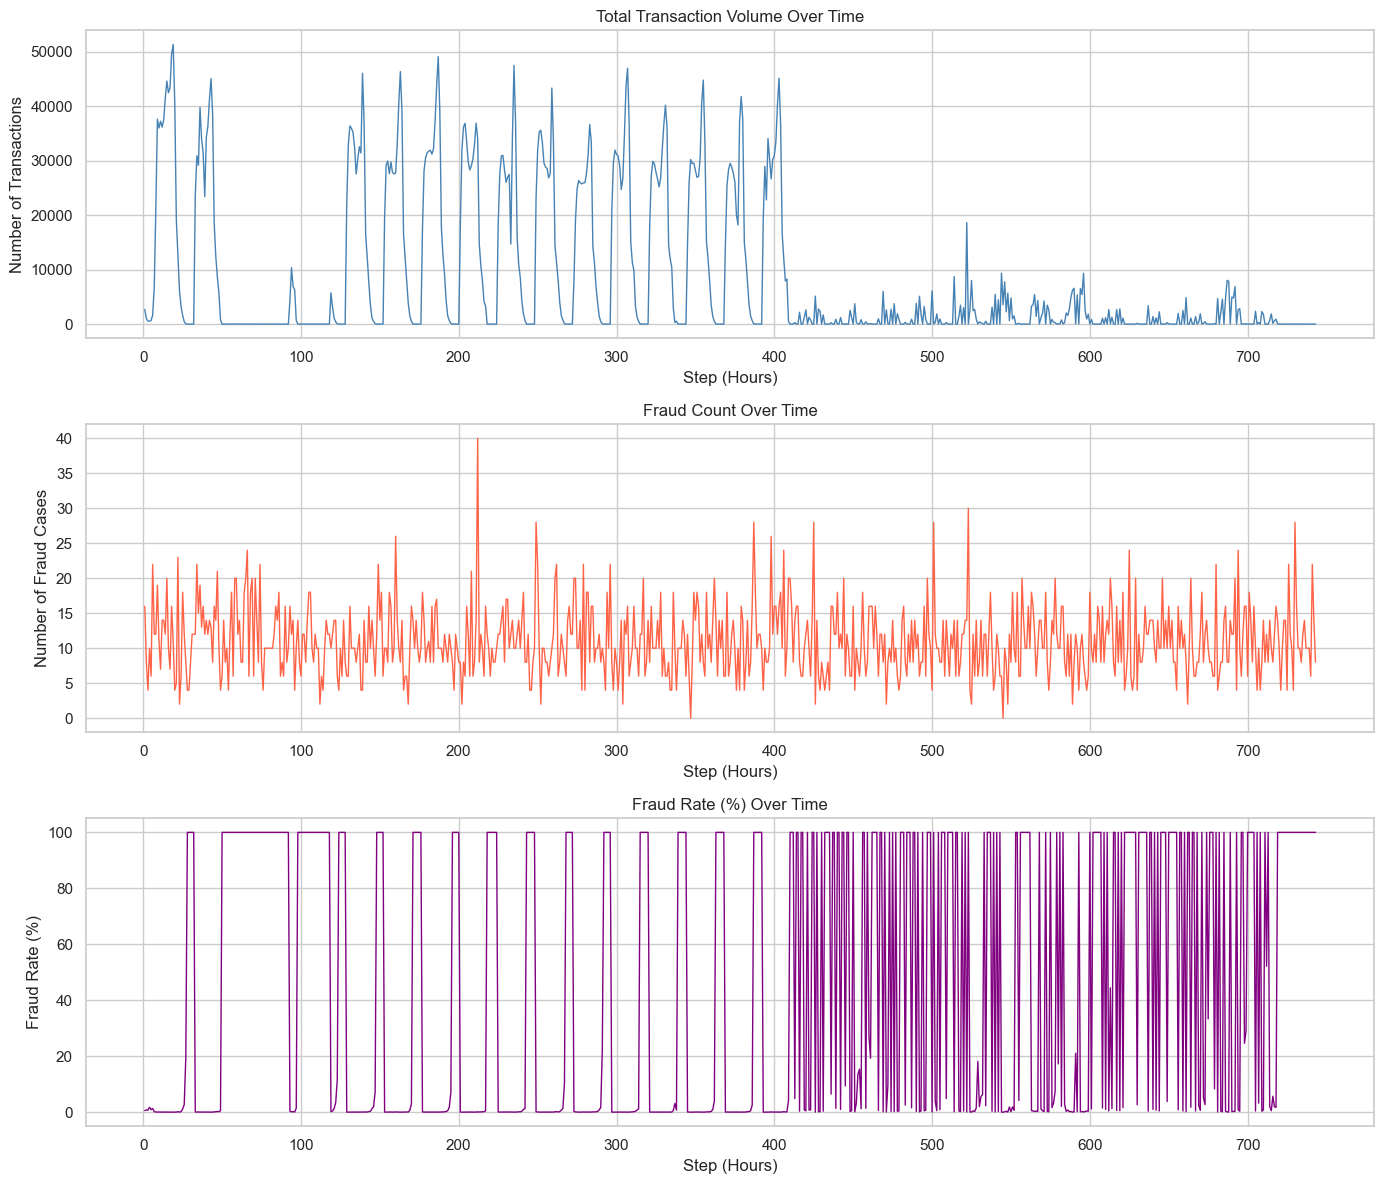

In [73]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Total transactions over time
axes[0].plot(fraud_over_time.index, fraud_over_time['total_count'], 
             color='steelblue', linewidth=1)
axes[0].set_title('Total Transaction Volume Over Time')
axes[0].set_xlabel('Step (Hours)')
axes[0].set_ylabel('Number of Transactions')

# Fraud count over time
axes[1].plot(fraud_over_time.index, fraud_over_time['fraud_count'], 
             color='tomato', linewidth=1)
axes[1].set_title('Fraud Count Over Time')
axes[1].set_xlabel('Step (Hours)')
axes[1].set_ylabel('Number of Fraud Cases')

# Fraud rate over time
axes[2].plot(fraud_over_time.index, fraud_over_time['fraud_rate'], 
             color='purple', linewidth=1)
axes[2].set_title('Fraud Rate (%) Over Time')
axes[2].set_xlabel('Step (Hours)')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

- Total transaction volume follows a clear cyclical pattern reflecting daily activity cycles, concentrated in the first 400 hours. However fraud count remains relatively stable throughout the entire simulation period — averaging 10–20 cases per step regardless of overall volume. This means fraud rate spikes dramatically after step 400 not because fraud increases but because legitimate transactions decline sharply, creating small sample bias in the rate calculation. This finding suggests that step alone is not a strong fraud predictor as fraud occurs consistently across all time periods.

---
### 9. Multivariate Analysis

#### 9.1 Correlation Heatmap

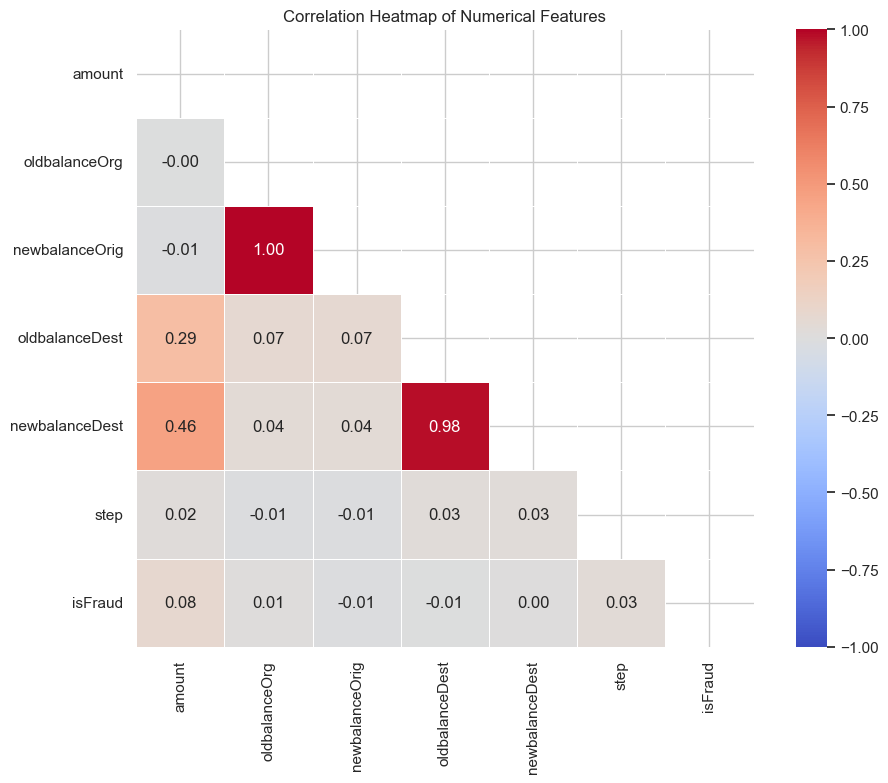

In [ ]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
            'oldbalanceDest', 'newbalanceDest', 'step', 'isFraud']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask, 
            annot=True,          # Show correlation values
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # Red = positive, Blue = negative
            vmin=-1, vmax=1,     # Fix scale
            linewidths=0.5,      # Grid lines between cells
            square=True)         # Square cells
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()

- The correlation heatmap reveals two pairs of highly correlated features — oldbalanceOrg/newbalanceOrig (r=1.00) and oldbalanceDest/newbalanceDest (r=0.98) — indicating multicollinearity. All features show weak linear correlation with isFraud, which is expected given the non-linear nature of fraud patterns and the severe class imbalance. These low correlations do not disqualify these features — tree-based models are capable of capturing complex non-linear relationships that linear correlation cannot measure. The highly correlated pairs will be addressed during feature engineering by creating balance difference features.

---
#### 9.2 Scatterplot for Amount vs Balance by Fraud Status

In [90]:
# Sample the data - stratified to keep fraud cases represented
fraud = df[df['isFraud'] == 1]          # All 8,213 fraud cases
non_fraud = df[df['isFraud'] == 0].sample(8213, random_state=42)  # Equal sample of non-fraud
sample_df = pd.concat([fraud, non_fraud]).reset_index(drop=True)

print(f"Sample shape: {sample_df.shape}")
print(sample_df['isFraud'].value_counts())

Sample shape: (16426, 12)
isFraud
1    8213
0    8213
Name: count, dtype: int64


- Here I only took a stratified sample from the whole dataset since it would take a lot of time and resources for the machine to process all 6 million rows of data.

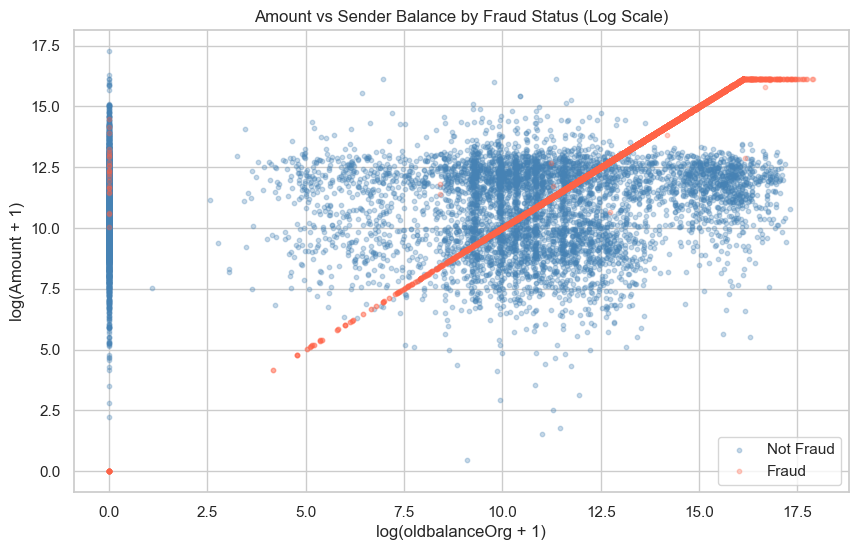

In [83]:
plt.figure(figsize=(10, 6))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = sample_df[sample_df['isFraud'] == label]
    plt.scatter(np.log1p(subset['oldbalanceOrg']),
                np.log1p(subset['amount']),
                alpha=0.3, s=10, color=color,
                label='Not Fraud' if label == 0 else 'Fraud')

plt.title('Amount vs Sender Balance by Fraud Status (Log Scale)')
plt.xlabel('log(oldbalanceOrg + 1)')
plt.ylabel('log(Amount + 1)')
plt.legend()
plt.show()

- The scatter plot reveals a striking pattern — fraudulent transactions form a clear diagonal line indicating that transaction amount closely matches the sender's account balance. This confirms that fraud involves deliberately draining accounts completely regardless of the balance size. This interaction between amount and sender balance is a powerful multivariate fraud signal that is invisible when examining either feature individually, and strongly motivates the creation of a balance difference feature during feature engineering.

---
#### 9.3 Boxplot for Amount by Type and Fraud Status

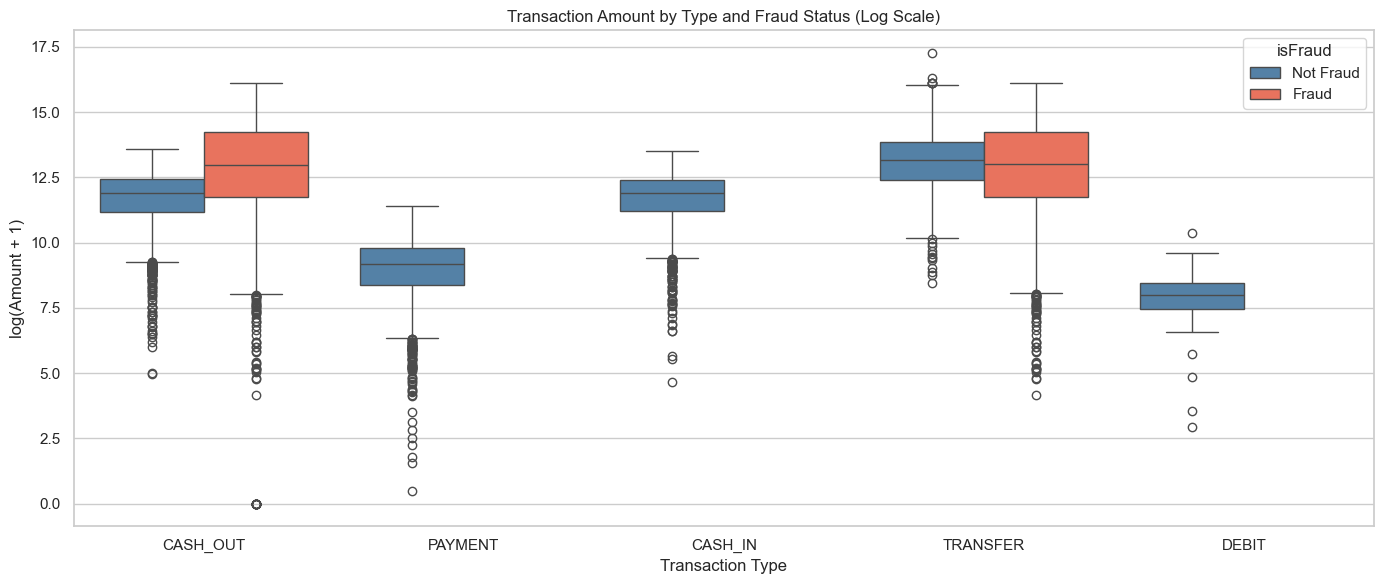

In [87]:
plt.figure(figsize=(14, 6))

ax = sns.boxplot(data=sample_df, x='type', y=np.log1p(sample_df['amount']),
            hue='isFraud',
            palette={0: 'steelblue', 1: 'tomato'},
            order=['CASH_OUT', 'PAYMENT', 'CASH_IN', 'TRANSFER', 'DEBIT'])

plt.title('Transaction Amount by Type and Fraud Status (Log Scale)')
plt.xlabel('Transaction Type')
plt.ylabel('log(Amount + 1)')

# Fix legend properly
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Not Fraud', 'Fraud'], title='isFraud')

plt.tight_layout()
plt.show()

- Combining transaction type and amount reveals nuanced patterns. Fraudulent CASH_OUT transactions involve significantly higher amounts than legitimate ones, making amount a useful discriminator for this type. However fraudulent TRANSFER transactions show heavy overlap with legitimate transfers in terms of amount, suggesting that amount alone is insufficient to detect TRANSFER fraud and must be combined with other features such as balance information. 

---
### 10. Hypothesis Summary

- By conducting EDA from this Financial Dataset, I formulated seven hypotheses. Each will be answered after conducting machine learning.

`H1 — Transaction type is a strong fraud predictor`

- Since fraud occurs exclusively in TRANSFER and CASH_OUT, transaction type will be among the most important features in the model.

`H2 — Account drainage is the strongest individual fraud signal`

- The difference between oldbalanceOrg and newbalanceOrig captures the account draining behavior and will be the most predictive engineered feature.


`H3 — Sender balance features outperform destination balance features`

- Based on the strong separation seen in sender balance columns vs the weak separation in destination balance columns, sender features will contribute more to model performance.

`H4 — Accuracy is a misleading evaluation metric`

- Due to severe class imbalance a model optimized for accuracy will fail to detect fraud. Precision, Recall, F1-Score and AUC-ROC are the appropriate metrics.

`H5 — Step is among the least important features`

- Since fraud occurs consistently across all time periods regardless of transaction volume, step will contribute minimally to model performance.

`H6 — No single feature can reliably detect fraud alone`

- The combination of transaction type, account drainage, and amount is necessary for strong fraud detection — no individual feature provides sufficient separation between fraud and non-fraud.

`H7 — Removing multicollinear features will not hurt model performance`

- Since oldbalanceOrg/newbalanceOrig and oldbalanceDest/newbalanceDest are nearly perfectly correlated, dropping one from each pair or replacing them with difference features will maintain or improve model performance.

---
### Conclusion

- Initial exploratory data analysis reveals consistent and detectable fraud patterns. I also uncovered that fraud is exclusively limited to TRANSFER and CASH_OUT transactions, almost always results in complete sender account drainage, and tends to target higher balance accounts. The severe class imbalance of 0.129% requires careful handling through resampling or class weighting, and model evaluation must rely on Precision, Recall and AUC-ROC rather than accuracy. Seven hypotheses have been formulated from these findings and will be tested during feature engineering and modeling.